In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [168]:
df = pd.read_csv('./FeatureEngineering/gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [169]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,NaN,NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,NaN,1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


1. price

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

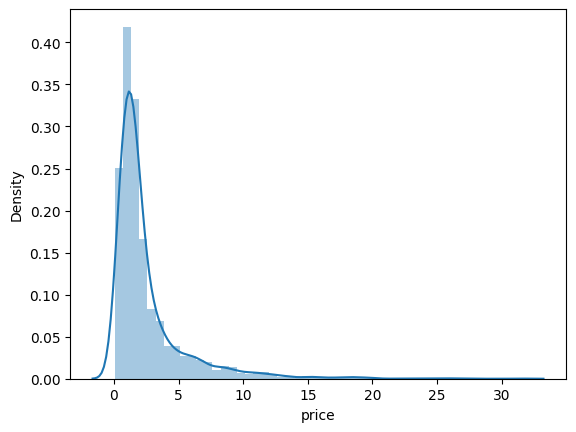

In [170]:
sns.distplot(df['price'])

<Axes: ylabel='price'>

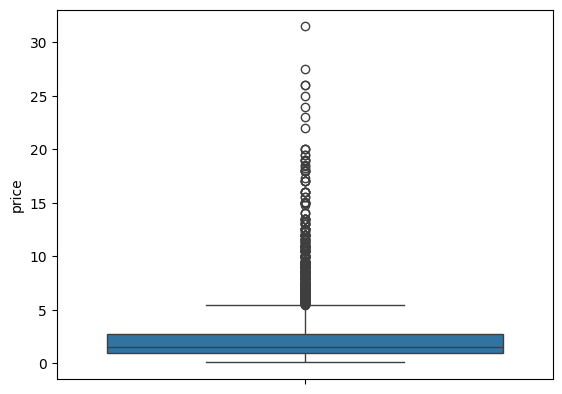

In [171]:
sns.boxplot(df['price'])

In [172]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [173]:
outliers.sort_values('price',ascending=False).sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3404,house,sector 15 part 2 rwa,sector 15,10.0,22222.0,4500.0,Plot area 502(419.74 sq.m.),5,5,2,2.0,East,NaN,NaN,NaN,0,0,0,0,0,Old Property,Unfurnished,28,4.62
3069,house,independent,sector 41,7.0,28283.0,2475.0,Plot area 275(229.94 sq.m.),7,7,3+,3.0,South-West,NaN,NaN,NaN,1,1,1,1,0,Moderately Old,Semi-Furnished,86,5.00
367,flat,paras quartier,gwal pahari,5.9,11028.0,5350.0,Super Built up area 5350(497.03 sq.m.),4,4,3+,19.0,East,5350.0,NaN,NaN,1,1,1,1,0,New Property,Furnished,106,NaN
3650,house,independent,sector 54,5.5,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,NaN,NaN,NaN,0,1,0,0,0,Relatively New,Semi-Furnished,34,4.62
3722,house,independent,sector 25,11.0,35530.0,3096.0,Plot area 344(287.63 sq.m.),5,5,3+,2.0,NaN,NaN,NaN,NaN,1,1,1,1,0,Relatively New,Unfurnished,19,5.00


In [174]:
# mask = (df.index.isin(outliers.index)) & (df['area'] < 1000)

# df.loc[mask, 'area'] = df.loc[mask, 'area'] * 9

2. price_per_sqft

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

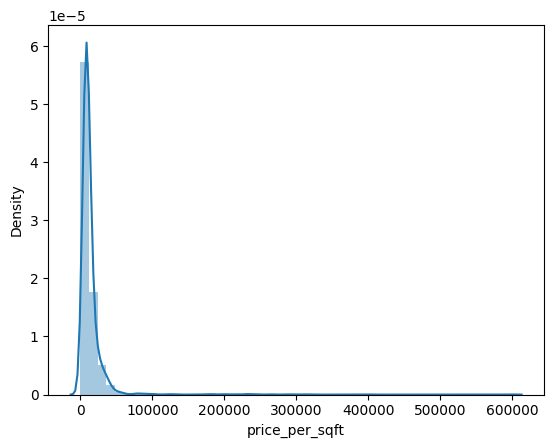

In [175]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

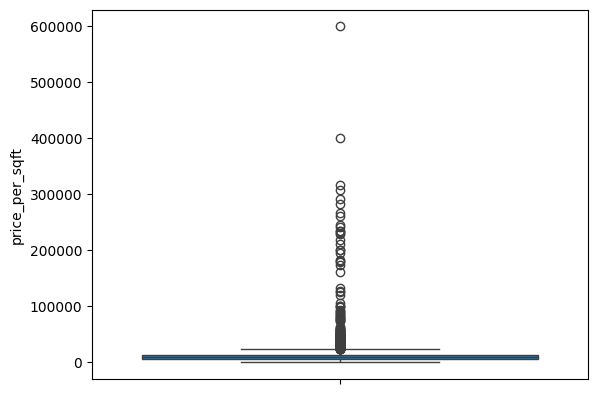

In [176]:
sns.boxplot(df['price_per_sqft'])

In [177]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [178]:
outliers_sqft['area']=outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

In [179]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

In [180]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [181]:
df.update(outliers_sqft)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

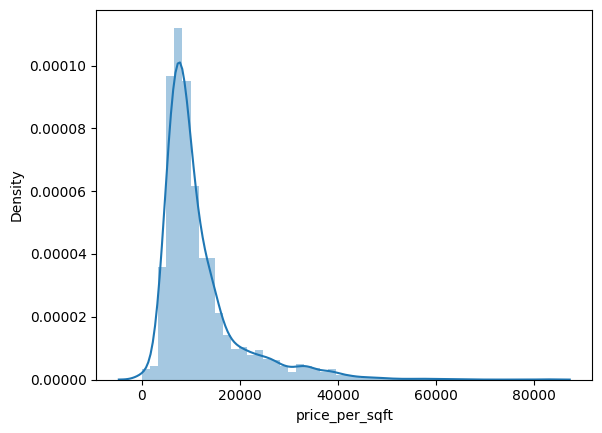

In [182]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

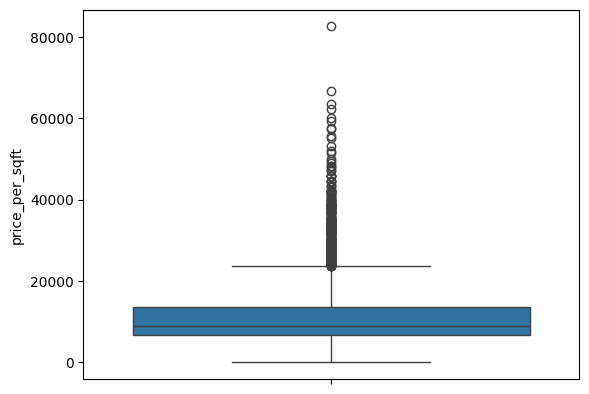

In [183]:
sns.boxplot(df['price_per_sqft'])

In [184]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
2659,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,NaN,1565.0,NaN,0,0,0,0,0,Undefined,Unfurnished,0,3.62
3147,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,NaN,1600.0,NaN,0,0,0,0,0,New Property,Furnished,65,4.75
3304,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,NaN,140.0,NaN,0,0,0,0,0,Undefined,Unfurnished,0,4.75
3418,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,NaN,NaN,NaN,0,0,0,0,0,Moderately Old,Unfurnished,0,NaN
3433,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,NaN,NaN,NaN,1,1,1,1,0,New Property,Furnished,89,5.00
3441,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,NaN,NaN,NaN,1,1,0,1,0,Old Property,Furnished,70,4.25
3476,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,NaN,400.0,350.0,1,1,1,1,0,New Property,Semi-Furnished,39,5.00
3518,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,NaN,NaN,NaN,1,1,0,1,1,New Property,Furnished,78,5.00
3603,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,NaN,NaN,NaN,1,1,0,0,0,Old Property,Furnished,96,4.25
3667,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,NaN,NaN,NaN,1,1,0,1,0,Moderately Old,Semi-Furnished,48,3.75


In [185]:
df=df[df['price_per_sqft']<=50000]

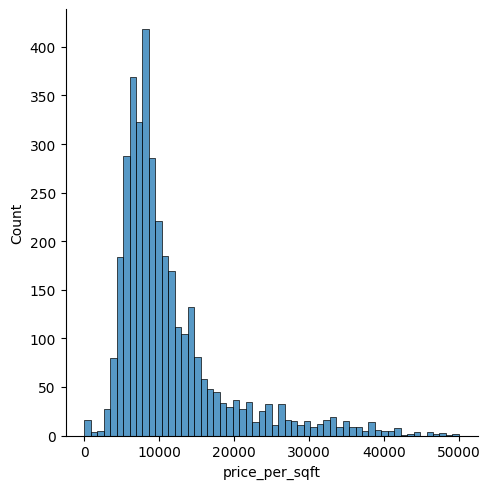

In [186]:
sns.displot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

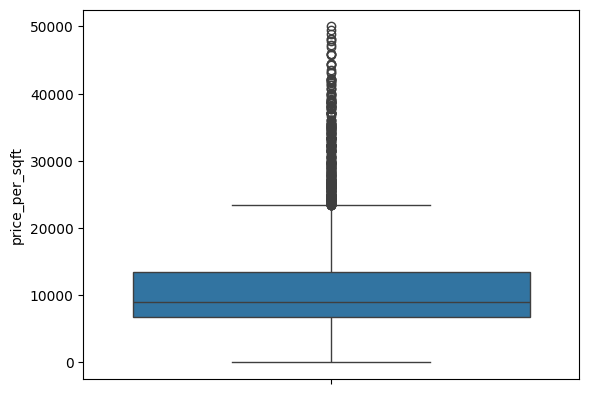

In [187]:
sns.boxplot(df['price_per_sqft'])

3. Area

In [188]:
df['area'].describe()

count      3651.000000
mean       2945.894276
std       23195.393199
min         145.000000
25%        1261.500000
50%        1750.000000
75%        2347.000000
max      875000.000000
Name: area, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

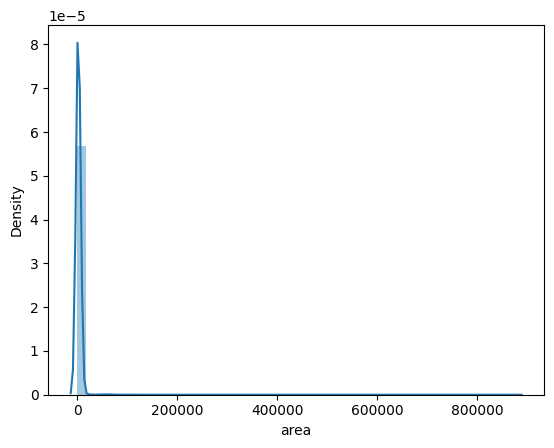

In [189]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

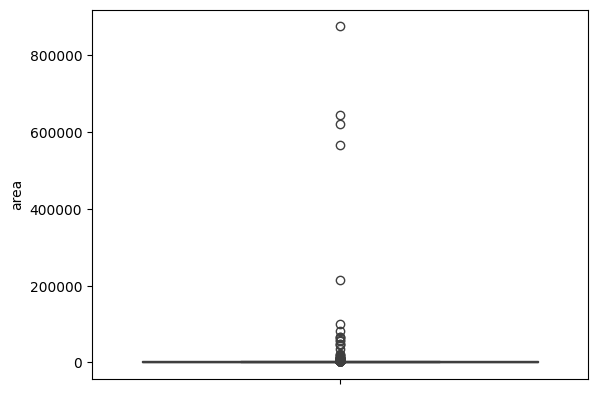

In [190]:
sns.boxplot(df['area'])

In [191]:
df=df[df['area']<100000]

In [192]:
df[df['area']>10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3559,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,NaN,NaN,11000.00,0,1,1,1,0,Relatively New,Furnished,38,5.00
3222,house,ganpati heights apartment,sector 13,1.250,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,NaN,NaN,NaN,0,0,0,0,1,Old Property,Unfurnished,3,4.00
1293,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,NaN,NaN,64412.00,0,0,0,0,0,Relatively New,Unfurnished,31,4.25
3294,house,dlf city plot phase 4,sector 28,13.000,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,NaN,NaN,7250.00,0,0,0,0,0,Undefined,Unfurnished,0,4.75
2304,flat,rof ananda,sector 95,0.375,58.0,64655.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,NaN,NaN,64529.00,1,0,0,0,0,New Property,Unfurnished,12,4.25
79,flat,pyramid elite,sector 86,0.460,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,NaN,NaN,58141.00,0,0,0,0,0,Under Construction,Unfurnished,12,4.75
1292,flat,rof ananda,sector 95,0.330,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,NaN,NaN,54917.00,0,0,0,0,0,Relatively New,Unfurnished,20,4.25
1415,flat,signature the serenas,sohna road,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,NaN,NaN,48811.00,1,0,0,0,0,Relatively New,Unfurnished,16,4.25
3471,house,independent,sector 25,7.300,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,NaN,5800.0,5200.00,0,1,1,0,0,Relatively New,Furnished,56,5.00
1289,flat,ramsons kshitij,sector 95,0.245,53.0,46226.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,NaN,NaN,45966.00,0,0,0,0,1,Relatively New,Unfurnished,19,4.10


In [193]:
df.drop(index=[3559,1293,2304,79,1292,1415,1289,1294],inplace=True)

In [194]:
df[df['area']>10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3222,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,NaN,NaN,NaN,0,0,0,0,1,Old Property,Unfurnished,3,4.00
3294,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,NaN,NaN,7250.00,0,0,0,0,0,Undefined,Unfurnished,0,4.75
3471,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,NaN,5800.0,5200.00,0,1,1,0,0,Relatively New,Furnished,56,5.00
3049,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,NaN,2660.0,2500.00,0,1,0,0,0,New Property,Furnished,34,4.00
3533,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,NaN,2850.0,2250.00,1,1,0,1,1,Moderately Old,Furnished,75,5.00
2399,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,NaN,NaN,18122.00,1,0,0,1,1,Relatively New,Furnished,22,4.88
3056,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,NaN,2160.0,1720.00,0,1,0,0,0,Moderately Old,Unfurnished,95,5.00
3042,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,NaN,NaN,NaN,0,0,0,0,1,Relatively New,Unfurnished,0,NaN
2801,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,NaN,NaN,1175.11,0,0,0,0,0,New Property,Unfurnished,39,NaN
3485,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,NaN,NaN,NaN,1,1,0,1,1,Relatively New,Furnished,26,5.00


In [195]:
df.loc[3222,'area'] = 115*9
df.loc[3294,'area'] = 7250
df.loc[3471,'area'] = 5800
df.loc[3049,'area'] = 2660
df.loc[3533,'area'] = 2850
df.loc[2399,'area'] = 1812
df.loc[3056,'area'] = 2160
df.loc[2801,'area'] = 1175

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

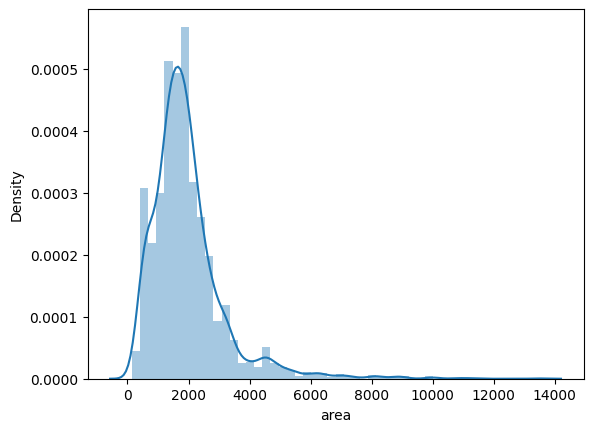

In [196]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

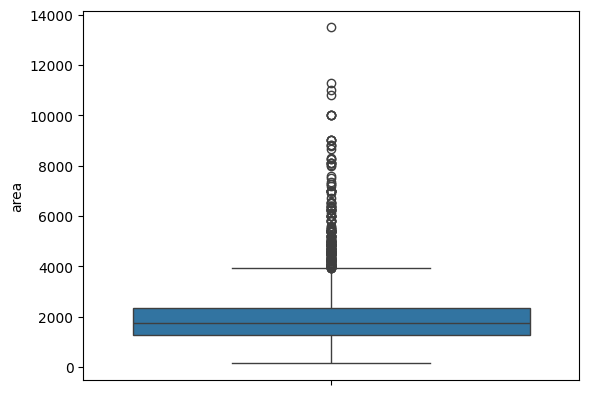

In [197]:
sns.boxplot(df['area'])

In [198]:
df['area'].describe()

count     3638.000000
mean      1952.768004
std       1230.214816
min        145.000000
25%       1260.000000
50%       1746.500000
75%       2325.000000
max      13492.000000
Name: area, dtype: float64

In [199]:
# 4. bedRoom

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

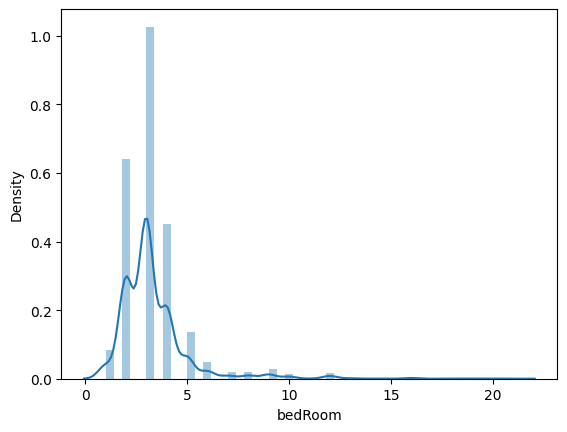

In [200]:
sns.distplot(df['bedRoom'])

<Axes: ylabel='bedRoom'>

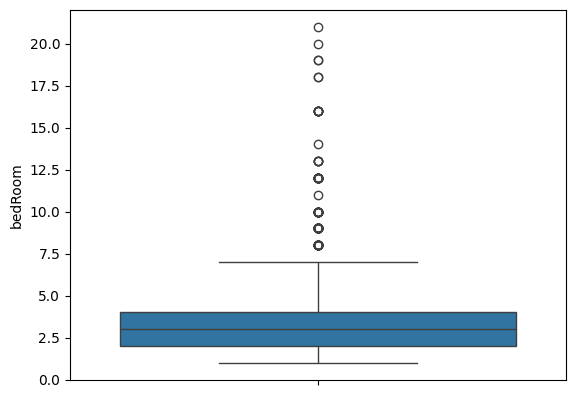

In [201]:
sns.boxplot(df['bedRoom'])

In [202]:
df['bedRoom'].describe()

count    3638.000000
mean        3.332325
std         1.829194
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [203]:
df[df['bedRoom']>10].sort_values('bedRoom')

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3487,house,independent,sector 43,2.25,7500.0,3000.0,Plot area 550(51.1 sq.m.)Built Up area: 3000 s...,11,11,3+,5.0,West,NaN,3000.0,NaN,0,0,0,0,1,New Property,Semi-Furnished,13,5.00
2946,house,independent,sector 43,3.00,5974.0,5022.0,Plot area 62(51.84 sq.m.),12,12,3+,5.0,West,NaN,NaN,NaN,0,0,0,0,1,New Property,Semi-Furnished,9,5.00
2980,house,independent,sector 55,7.49,27741.0,2700.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Furnished,28,4.25
2976,house,floor wise designer kothi,sector 25,13.00,48148.0,2700.0,Plot area 300(250.84 sq.m.),12,16,3+,4.0,North-East,NaN,NaN,NaN,1,1,1,1,0,New Property,Semi-Furnished,75,5.00
3002,house,independent,sector 40,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,4.0,NaN,NaN,NaN,NaN,0,0,1,0,0,New Property,Furnished,21,4.00
3016,house,independent,sector 56,11.50,42032.0,2736.0,Plot area 304(254.18 sq.m.),12,13,3+,4.0,West,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Furnished,28,4.50
3557,house,independent,sector 14,8.00,17707.0,4518.0,Plot area 502(419.74 sq.m.),12,4,3+,3.0,North,NaN,NaN,NaN,0,1,1,0,0,Old Property,Unfurnished,21,3.50
2982,house,independent,sector 56,11.95,43534.0,2745.0,Plot area 305(255.02 sq.m.),12,12,3+,4.0,West,NaN,NaN,NaN,0,1,0,0,0,Relatively New,Furnished,11,4.50
3448,house,independent,sector 46,6.81,36911.0,1845.0,Plot area 205(171.41 sq.m.),12,14,3+,NaN,East,NaN,NaN,NaN,0,1,0,0,1,New Property,Furnished,18,4.25
3481,house,dlf city plots phase 2,sector 25,10.00,44444.0,2250.0,Plot area 250(23.23 sq.m.),12,12,3+,4.0,North,NaN,NaN,NaN,1,1,0,0,0,Relatively New,Furnished,58,5.00


In [204]:
def remove_unrealistic_bhk(df):
    mask = (
        (df['bedRoom'].between(11, 21)) &
        (df['area'] < df['bedRoom'] * 200)
    )
    
    df.drop(index=df[mask].index, inplace=True)
    
    return df.head()

remove_unrealistic_bhk(df)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,NaN,NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,NaN,1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [205]:
df[df['bedRoom']>10].sort_values('bedRoom')

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3487,house,independent,sector 43,2.25,7500.0,3000.0,Plot area 550(51.1 sq.m.)Built Up area: 3000 s...,11,11,3+,5.0,West,NaN,3000.0,NaN,0,0,0,0,1,New Property,Semi-Furnished,13,5.00
2946,house,independent,sector 43,3.00,5974.0,5022.0,Plot area 62(51.84 sq.m.),12,12,3+,5.0,West,NaN,NaN,NaN,0,0,0,0,1,New Property,Semi-Furnished,9,5.00
2980,house,independent,sector 55,7.49,27741.0,2700.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Furnished,28,4.25
2976,house,floor wise designer kothi,sector 25,13.00,48148.0,2700.0,Plot area 300(250.84 sq.m.),12,16,3+,4.0,North-East,NaN,NaN,NaN,1,1,1,1,0,New Property,Semi-Furnished,75,5.00
3016,house,independent,sector 56,11.50,42032.0,2736.0,Plot area 304(254.18 sq.m.),12,13,3+,4.0,West,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Furnished,28,4.50
3582,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,4.0,North-East,NaN,300.0,270.0,0,1,0,1,0,Relatively New,Furnished,38,5.00
3557,house,independent,sector 14,8.00,17707.0,4518.0,Plot area 502(419.74 sq.m.),12,4,3+,3.0,North,NaN,NaN,NaN,0,1,1,0,0,Old Property,Unfurnished,21,3.50
2982,house,independent,sector 56,11.95,43534.0,2745.0,Plot area 305(255.02 sq.m.),12,12,3+,4.0,West,NaN,NaN,NaN,0,1,0,0,0,Relatively New,Furnished,11,4.50
3696,house,independent,sector 43,2.20,6875.0,3200.0,Plot area 3200(297.29 sq.m.),12,12,3+,6.0,North,NaN,NaN,NaN,0,1,0,0,0,New Property,Semi-Furnished,25,4.88
3754,house,independent,sector 28,11.00,33951.0,3240.0,Plot area 360(301.01 sq.m.),13,13,3+,3.0,East,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Semi-Furnished,64,4.75


In [206]:
df['bedRoom'].describe()

count    3607.000000
mean        3.241475
std         1.529763
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        19.000000
Name: bedRoom, dtype: float64

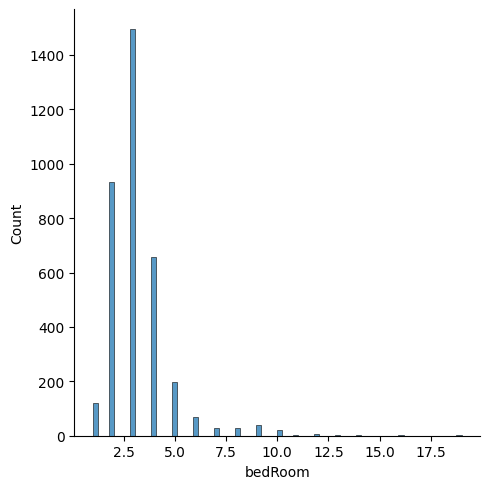

In [207]:
sns.displot(df['bedRoom'])

5. bathroom

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

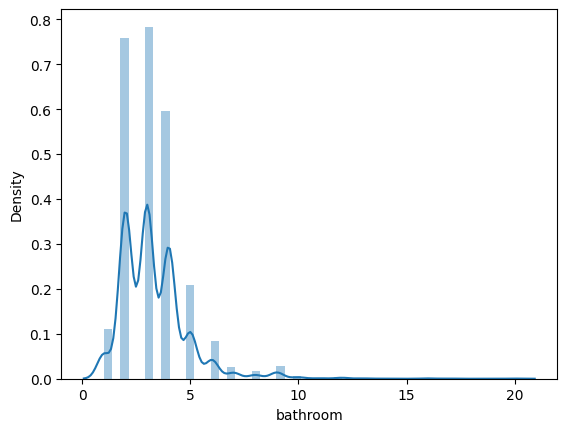

In [208]:
sns.distplot(df['bathroom'])

<Axes: ylabel='bathroom'>

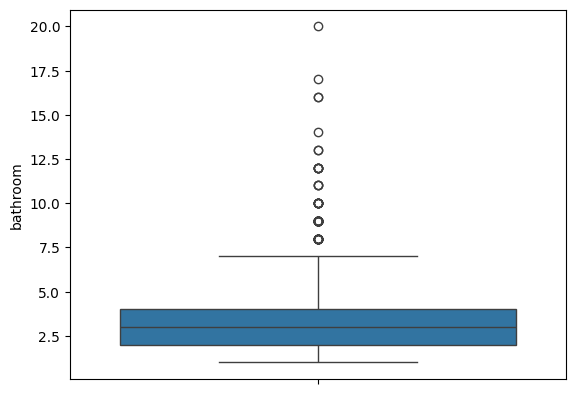

In [209]:
sns.boxplot(df['bathroom'])

In [210]:
df[df['bathroom']>10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3434,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,NaN,NaN,NaN,1,1,1,1,0,New Property,Furnished,89,5.00
3402,house,independent,sector 17,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,NaN,7500.0,NaN,1,0,1,0,0,Relatively New,Unfurnished,34,4.50
2949,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,NaN,NaN,NaN,0,1,0,0,0,New Property,Furnished,24,5.00
2976,house,floor wise designer kothi,sector 25,13.00,48148.0,2700.0,Plot area 300(250.84 sq.m.),12,16,3+,4.0,North-East,NaN,NaN,NaN,1,1,1,1,0,New Property,Semi-Furnished,75,5.00
3219,house,independent,sector 24,3.20,6584.0,4860.0,Plot area 60(50.17 sq.m.),14,14,3+,6.0,West,NaN,NaN,NaN,0,0,0,0,0,Relatively New,Semi-Furnished,6,4.50
3754,house,independent,sector 28,11.00,33951.0,3240.0,Plot area 360(301.01 sq.m.),13,13,3+,3.0,East,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Semi-Furnished,64,4.75
3016,house,independent,sector 56,11.50,42032.0,2736.0,Plot area 304(254.18 sq.m.),12,13,3+,4.0,West,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Furnished,28,4.50
2980,house,independent,sector 55,7.49,27741.0,2700.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,NaN,NaN,NaN,1,1,0,1,0,Relatively New,Furnished,28,4.25
3696,house,independent,sector 43,2.20,6875.0,3200.0,Plot area 3200(297.29 sq.m.),12,12,3+,6.0,North,NaN,NaN,NaN,0,1,0,0,0,New Property,Semi-Furnished,25,4.88
2982,house,independent,sector 56,11.95,43534.0,2745.0,Plot area 305(255.02 sq.m.),12,12,3+,4.0,West,NaN,NaN,NaN,0,1,0,0,0,Relatively New,Furnished,11,4.50


In [211]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.0


6. super-build-up area

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

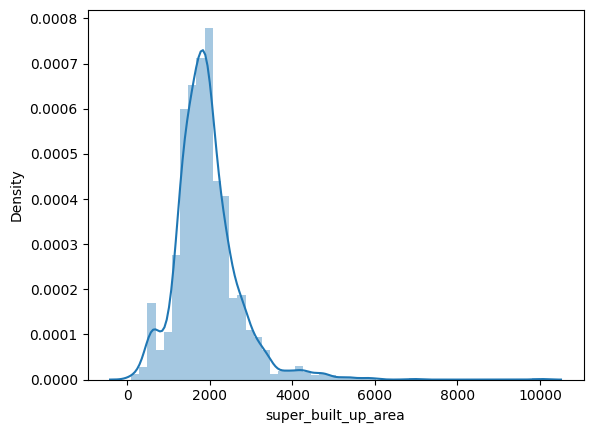

In [212]:
sns.distplot(df['super_built_up_area'])

<Axes: ylabel='super_built_up_area'>

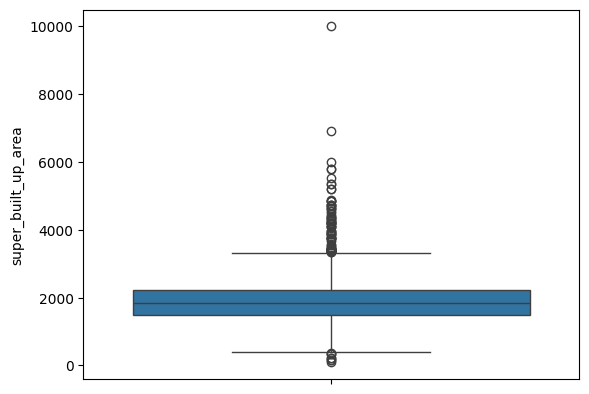

In [213]:
sns.boxplot(df['super_built_up_area'])

In [214]:
df[df['super_built_up_area']>6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
657,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,10000.0,NaN,NaN,0,1,0,1,1,Relatively New,Unfurnished,23,NaN
1528,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,6926.0,NaN,NaN,0,1,0,0,0,Relatively New,Furnished,91,5.0


In [215]:
df['super_built_up_area'].describe()

count     1876.000000
mean      1925.357436
std        763.985994
min         89.000000
25%       1479.750000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

7. built-up area

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

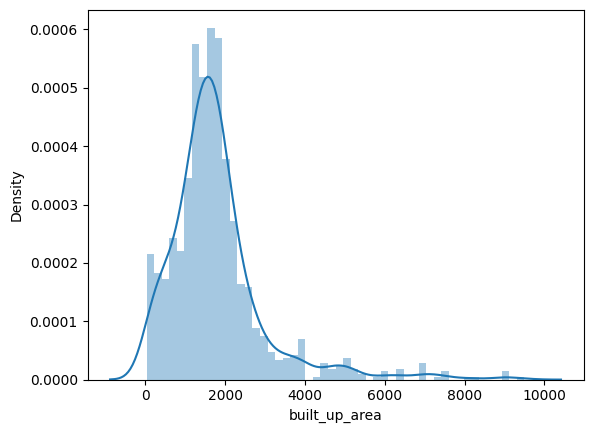

In [216]:
sns.distplot(df['built_up_area'])

<Axes: ylabel='built_up_area'>

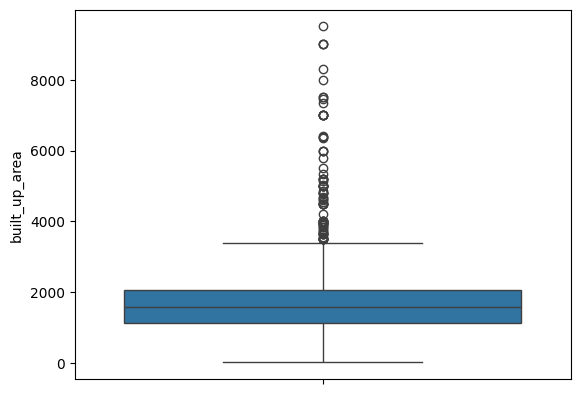

In [217]:
sns.boxplot(df['built_up_area'])

In [218]:
df[df['built_up_area']>8000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3153,house,anamika enclave,sector 12,6.0,14492.0,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9,9,3+,3.0,North-West,NaN,9000.0,NaN,0,0,0,0,0,Old Property,Unfurnished,10,4.62
3160,house,independent,sector 56,8.0,9654.0,8287.0,Plot area 362(33.63 sq.m.)Built Up area: 8286 ...,10,10,3+,4.0,NaN,NaN,8286.0,NaN,1,1,0,1,0,Relatively New,Semi-Furnished,56,4.50
3617,house,dlf alameda,sector 73,17.0,35109.0,4842.0,Plot area 4842(449.84 sq.m.)Built Up area: 900...,5,8,3,3.0,North-West,NaN,9000.0,NaN,1,1,1,1,0,Relatively New,Semi-Furnished,50,NaN
3618,house,ansal sushant lok plots,sector 43,11.5,17692.0,6500.0,Plot area 3762(349.5 sq.m.)Built Up area: 9000...,7,8,3+,3.0,NaN,NaN,9000.0,6500.0,0,1,1,1,0,Old Property,Furnished,21,4.88
3742,house,independent,sector 25,10.0,37037.0,2700.0,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,3.0,East,NaN,9500.0,9000.0,0,1,0,1,0,Moderately Old,Semi-Furnished,20,5.00


8. carpet area

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

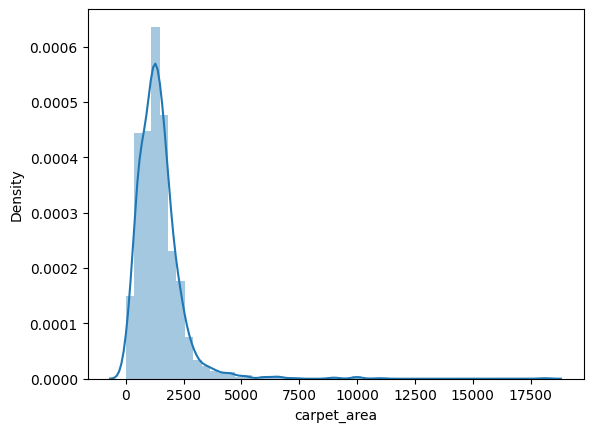

In [219]:
sns.distplot(df['carpet_area'])

<Axes: ylabel='carpet_area'>

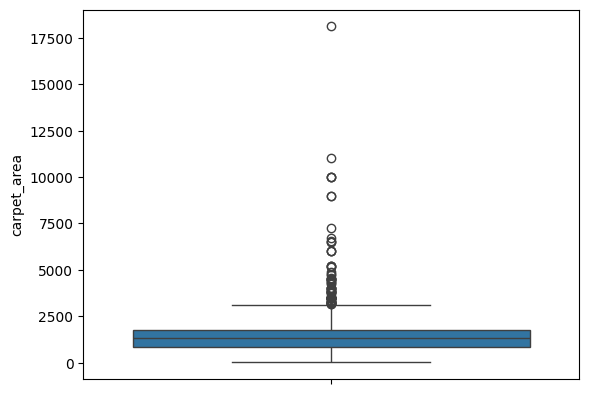

In [220]:
sns.boxplot(df['carpet_area'])

In [221]:
df[df['carpet_area']>10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
1622,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,NaN,NaN,11000.0,0,1,0,0,0,Moderately Old,Unfurnished,45,5.00
2399,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,NaN,NaN,18122.0,1,0,0,1,1,Relatively New,Furnished,22,4.88


In [222]:
df.loc[2399,'carpet_area']=1812

9. luxury_score

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

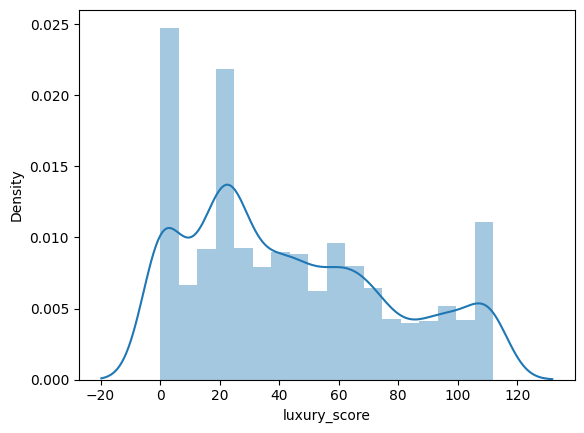

In [223]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

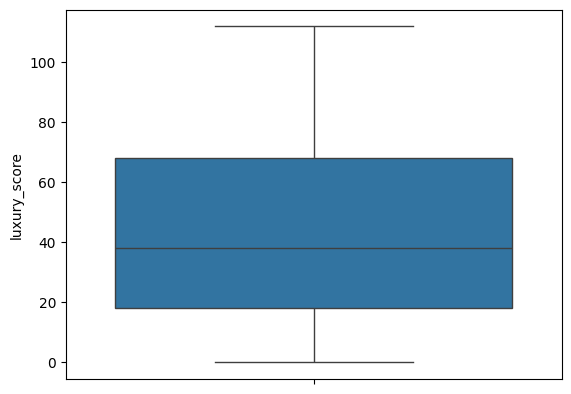

In [224]:
sns.boxplot(df['luxury_score'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

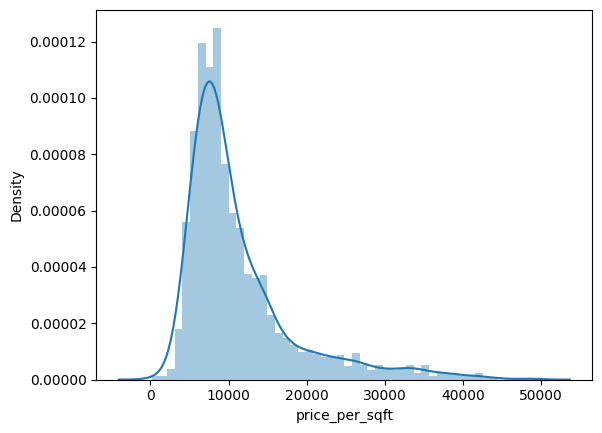

In [225]:
sns.distplot(df['price_per_sqft'])

In [226]:
# precation bcoz i have touched some area values
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20464\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

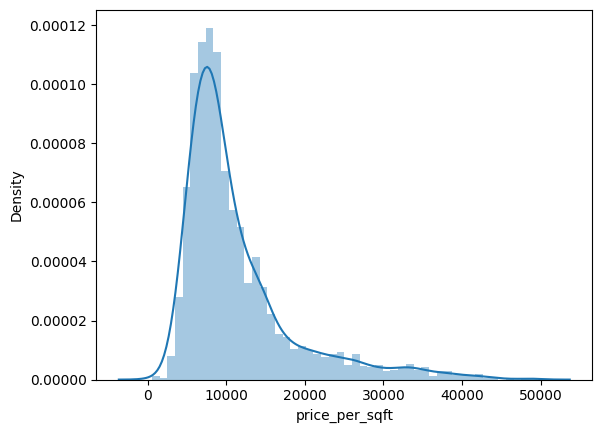

In [227]:
sns.distplot(df['price_per_sqft'])

In [228]:
df.shape

(3607, 24)

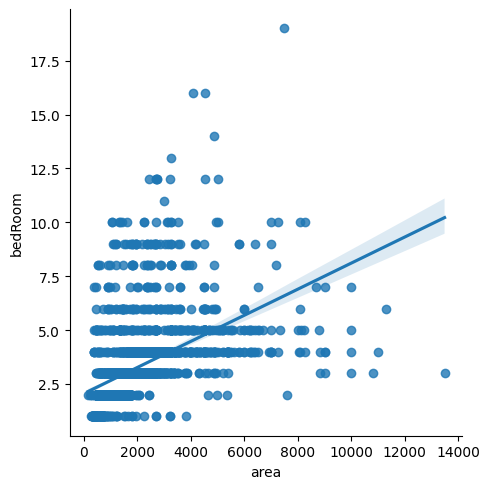

In [229]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [230]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(251.5)

In [231]:
df[df['area']/df['bedRoom']<250].sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
3455,house,independent,sector 55,1.45,26852.0,540.0,Plot area 60(5.57 sq.m.),4,4,3+,4.0,East,NaN,NaN,NaN,0,0,1,0,0,Relatively New,Unfurnished,40,4.25
3089,house,independent,sector 26,6.00,33333.0,1800.0,Plot area 200(167.23 sq.m.),8,5,3+,3.0,NaN,NaN,NaN,NaN,0,0,0,0,0,Old Property,Furnished,10,5.00
1312,flat,rof ananda,sector 95,0.37,5745.0,644.0,Carpet area: 644.12 (59.84 sq.m.),3,2,1,6.0,South-East,NaN,NaN,644.12,0,0,0,1,0,Relatively New,Furnished,45,4.25
3194,house,independent,sector 4,1.10,6111.0,1800.0,Plot area 200(167.23 sq.m.),8,4,3+,2.0,West,NaN,NaN,NaN,0,0,0,0,0,Old Property,Unfurnished,2,4.25
3211,house,independent,sector 8,0.82,10224.0,802.0,Carpet area: 802 (74.51 sq.m.),4,4,0,2.0,NaN,NaN,NaN,802.00,0,0,0,0,0,Undefined,Unfurnished,0,4.25


In [232]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [244]:
df.shape

(3607, 25)

In [245]:
df=df[df['area_room_ratio']>100]

In [246]:
df.shape

(3587, 25)

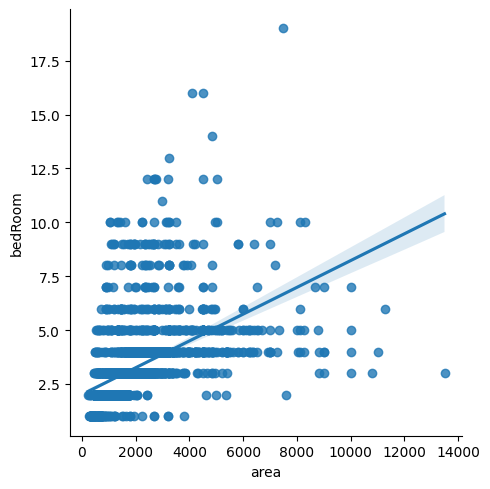

In [247]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [248]:
df.shape

(3587, 25)

In [249]:
outlier_df=df[(df['area_room_ratio']<250) & (df['bedRoom']>3)]

In [250]:
outlier_df['bedRoom']=round(outlier_df['bedRoom']/outlier_df['floorNum'])

In [251]:
outlier_df.shape

(92, 25)

In [252]:
df.update(outlier_df)

In [253]:
df.shape

(3587, 25)

In [254]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [256]:
df[(df['area_room_ratio']<250)&(df['bedRoom']>4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,area_room_ratio
3081,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,1.0,NaN,NaN,NaN,NaN,0,0,0,0,0,New Property,Unfurnished,0,3.88,222.750000
3088,house,independent,manesar,0.80,6667.0,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,1.0,NaN,NaN,NaN,NaN,0,0,0,0,0,Relatively New,Unfurnished,0,4.12,150.000000
3090,house,shivpuri,sector 7,2.80,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,NaN,NaN,NaN,1,1,0,1,1,Old Property,Furnished,0,4.75,225.000000
3094,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,1.0,North-East,NaN,NaN,110.0,0,0,0,0,0,Undefined,Unfurnished,0,4.00,198.000000
3141,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,NaN,NaN,NaN,0,0,0,1,0,Old Property,Unfurnished,4,4.25,200.000000
3150,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,NaN,NaN,NaN,0,0,0,1,0,Old Property,Unfurnished,16,4.00,120.600000
3202,house,independent,sector 3 phase 2,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.0,East,NaN,1100.0,900.0,0,0,0,0,0,Undefined,Unfurnished,0,3.88,220.000000
3228,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,NaN,NaN,1000.0,0,0,0,0,0,Undefined,Unfurnished,0,4.00,166.666667
3243,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,NaN,NaN,900.0,0,0,0,0,0,Undefined,Unfurnished,0,4.00,150.000000
3300,house,independent,sector 17,0.32,5664.0,565.0,Built Up area: 565 (52.49 sq.m.),5,1,0,1.0,NaN,NaN,565.0,NaN,0,0,0,0,0,Undefined,Unfurnished,0,3.50,113.000000


In [259]:
df=df[~((df['area_room_ratio']<250)&(df['bedRoom']>4))]

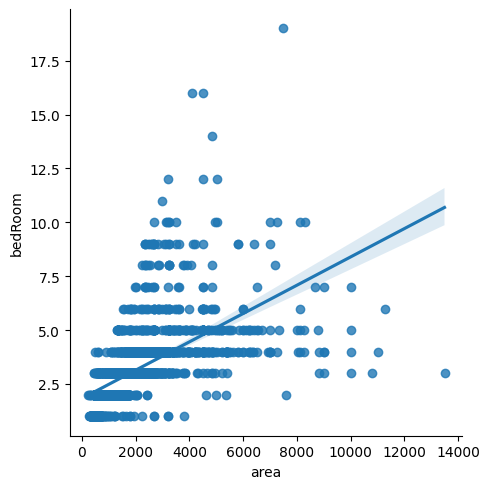

In [260]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [261]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)